### 데이터의 불균형 문제
- 정상을 정확하게 분류하는 것과 이상을 정확하게 분류하는 것중 이상을 정확하게 분류하는 것이 중요
- 일반적으로는 정상의 데이터가 이상의 데이터보다 많다.
- 데이터의 불균형이 발생할 수 있다.
- target 데이터에서 0(정상), 1(이상)중에 0을 판단을 더 많이 하게 되는 경우가 발생(예측력이 떨어진다.)
- 소수의 데이터의 중요도가 낮게 판단이 되서 실제 모델에서는 해당하는 예측이 적게 발생
- 다수의 데이터와 소수의 데이터를 특정 비율로 조절해주는 샘플링 기법이 존재 (언더 샘플링, 오버 샘플링)
- 샘플링을 사용하기 위한 라이브러리 설치 (imbalanced-learn)

In [169]:
# !pip install imbalanced-learn

- 언더 샘플링
    - 다수의 라벨을 가진 데이터를 샘플링 하여 소수의 데이터의 수 수준으로 감소 시키는 방법
    - 데이터의 불균형 문제는 해결이 되지만 전체 데이터의 개수가 감소하여 학습의 성능이 떨어질 수 있다.

In [170]:
import pandas as pd
from sklearn.datasets import make_classification
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

In [171]:
# 머신러닝에서는 독립 변수와 종속 변수를 이용
# make_classification() 함수는 데이터가 불균형한 랜덤 데이터를 생성 -> 결과가 독립변수, 종속변수 따로 데이터를 제공

# 불균형 데이터셋 생성
x, y = make_classification(
    n_samples = 1000,
    n_features = 5,
    weights = [0.9],
    flip_y = 0
)

In [172]:
x

array([[ 0.03193534, -2.19577057, -2.80865808,  0.38552628,  2.97270394],
       [ 0.83261356, -0.7739106 , -0.75290217, -0.17634058,  0.52983633],
       [ 0.44645873, -0.33842913, -0.09177336, -0.38992086, -0.28718485],
       ...,
       [ 0.57554266, -1.09609919, -0.79975041, -0.60092662,  0.16789235],
       [ 0.32504287, -0.14530018, -1.02000162,  1.1242949 ,  2.01935918],
       [ 0.4276518 ,  1.48161341,  1.08999171,  0.80048229, -0.24651471]],
      shape=(1000, 5))

In [173]:
y

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [174]:
Counter(y)

Counter({np.int64(0): 901, np.int64(1): 99})

In [175]:
# 데이터 프레임으로 생성
df = pd.DataFrame(x)
# target 데이터 y도 데이터프레임에 포함
df['target'] = y
df.head()

,0,1,2,3,4,target
0,0.031935,-2.195771,-2.808658,0.385526,2.972704,0
1,0.832614,-0.773911,-0.752902,-0.176341,0.529836,0
2,0.446459,-0.338429,-0.091773,-0.389921,-0.287185,1
3,-0.637972,0.493977,1.374887,-1.065494,-2.292320,1
4,0.446723,-0.728194,-0.581019,-0.333751,0.220147,0


In [176]:
# RandomUnderSampler 라는 class를 생성
undersampler = RandomUnderSampler()

In [177]:
under_x , under_y = undersampler.fit_resample(x, y)

In [178]:
Counter(under_y)

Counter({np.int64(0): 99, np.int64(1): 99})

In [179]:
under_df = pd.DataFrame(under_x)
under_df['target'] = under_y
under_df['target'].value_counts()

target
0    99
1    99
Name: count, dtype: int64

In [180]:
# undersampler에서 데이터의 비율을 변경
# class 생성할때 비율을 지정
# sampling_strategy 매개변수 -> 소수의 데이터의 비율을 의미
undersampler2 = RandomUnderSampler(sampling_strategy = 0.5)

In [181]:
x_under2, y_under2 = undersampler2.fit_resample(x, y)

In [182]:
Counter(y_under2)

Counter({np.int64(0): 198, np.int64(1): 99})

- 오버 샘플링
    - 소수의 데이터를 다수의 데이터의 개수만큼 증가시켜 학습에 사용하기 위한 방법
    - 데이터의 손실이 없기 때문에 일반적으로는 언더 샘플링보다는 자주 사용

- 랜덤오버 샘플링
    - 소수의 데이터를 단순 복제하여 다수의 데이터와의 비율을 맞춰주는 과정
    - 데이터가 단순하게 복제가 되기 때문에 데이터의 분포가 변하지 않는다.
    - 단순하게 증가시키기 때문에 추가적인 가중치가 발생
    - 오버피팅의 위험성이 존재하지만 데이터 불균형 문제를 해결하는것이 더 중요

In [183]:
from imblearn.over_sampling import RandomOverSampler

In [184]:
oversampler = RandomOverSampler()

In [185]:
over_x, over_y = oversampler.fit_resample(x, y)

In [186]:
Counter(over_y)

Counter({np.int64(0): 901, np.int64(1): 901})

In [187]:
# 소수의 데이터 비율을 다수의 반정도로 샘플링
oversampler2 = RandomOverSampler(sampling_strategy=0.5)

In [188]:
over_x2, over_y2 = oversampler2.fit_resample(x, y)

In [189]:
Counter(over_y2)

Counter({np.int64(0): 901, np.int64(1): 450})

- SMOTE
    - 소수의 데이터의 관측값에 대한 K개의 최근접 양수를 이웃으로 찾고, 관측값과 이웃으로 선택된 값 사이에 임의의 새로운 데이터를 생성하는 방법

In [190]:
from imblearn.over_sampling import SMOTE

In [191]:
smote = SMOTE()

In [192]:
sm_x, sm_y = smote.fit_resample(x, y)

In [193]:
Counter(sm_y)

Counter({np.int64(0): 901, np.int64(1): 901})

In [194]:
# 실제 만들어진 샘플링 데이터의 분포를 확인
import matplotlib.pyplot as plt
import seaborn as sns

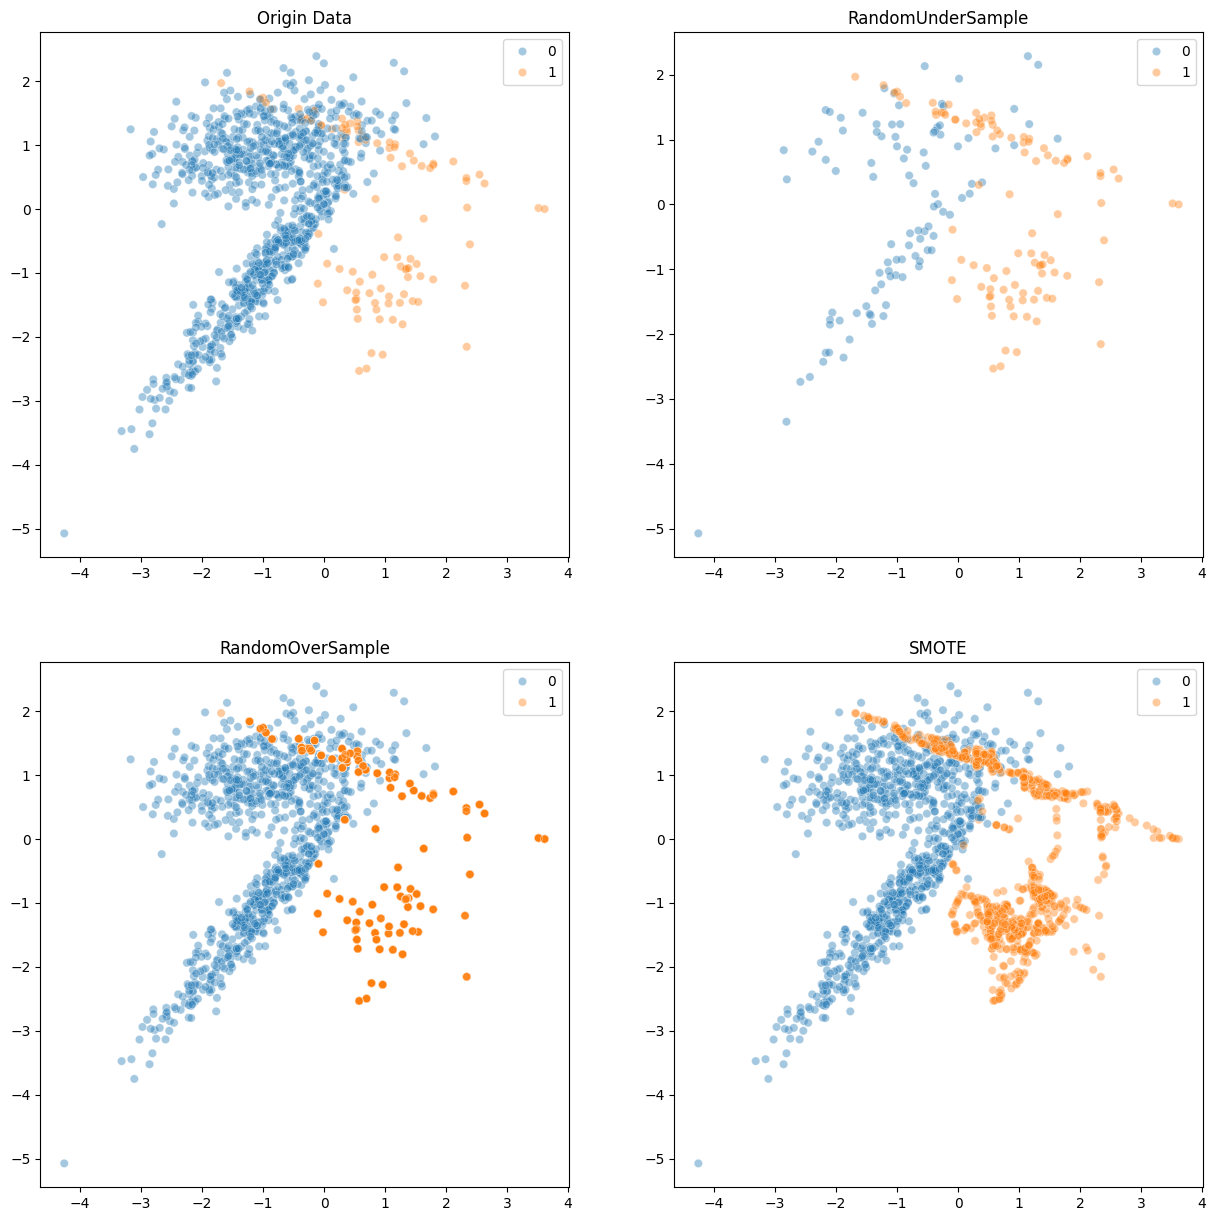

In [195]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# 4개의 산점도 그래프 생성
sns.scatterplot(
    x = x[:, 2], y = x[:, 3], ax=axes[0][0], hue = y, alpha = 0.4
)
sns.scatterplot(
    x = under_x[:, 2], y = under_x[:, 3], ax = axes[0][1], hue = under_y, alpha = 0.4
)
sns.scatterplot(
    x = over_x[: ,2], y = over_x[:, 3], ax = axes[1][0], hue = over_y, alpha = 0.4
)
sns.scatterplot(
    x = sm_x[: ,2], y = sm_x[:, 3], ax = axes[1][1], hue = sm_y, alpha = 0.4
)
axes[0][0].set_title('Origin Data')
axes[0][1].set_title('RandomUnderSample')
axes[1][0].set_title('RandomOverSample')
axes[1][1].set_title('SMOTE')
plt.show()